In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.stats import sigma_clip
from scipy.stats import binned_statistic

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

N_train = 446  N_test = 112
Test RMSE: 0.1868
Test  MAE: 0.1435
Test   R2: 0.8287


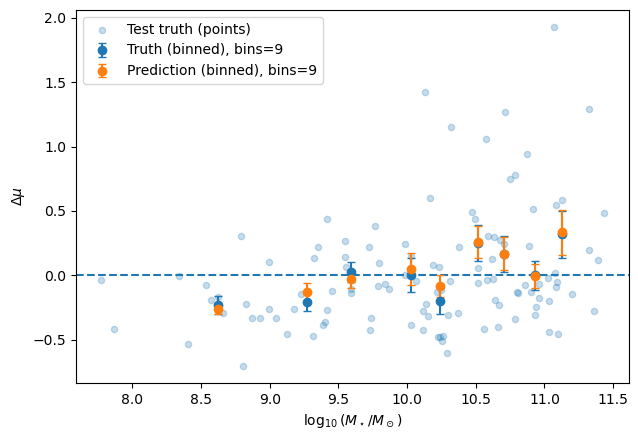

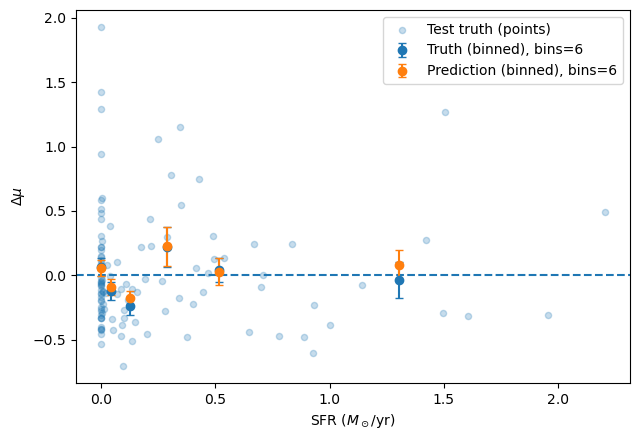

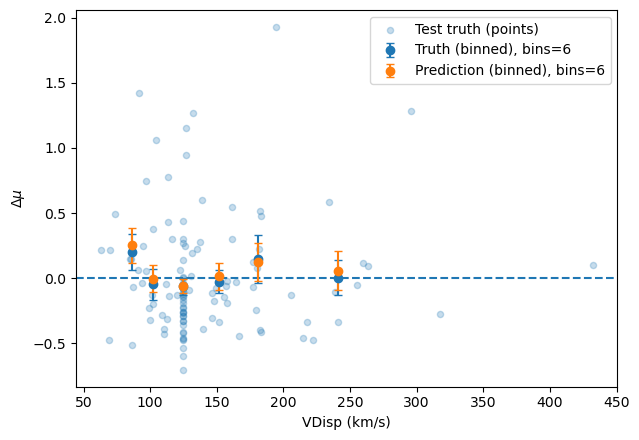

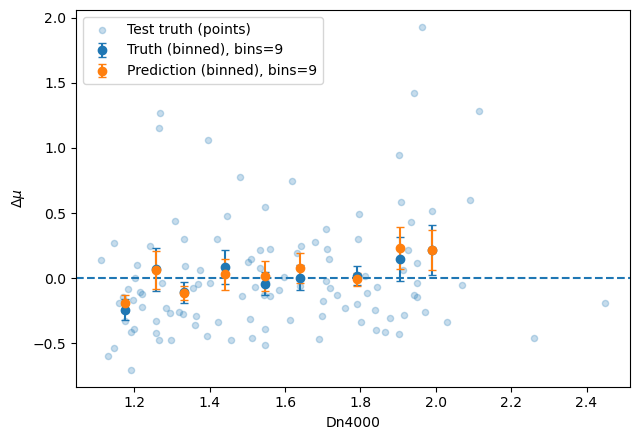

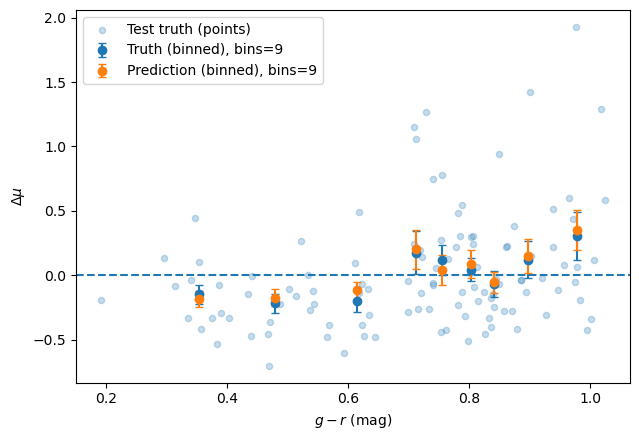

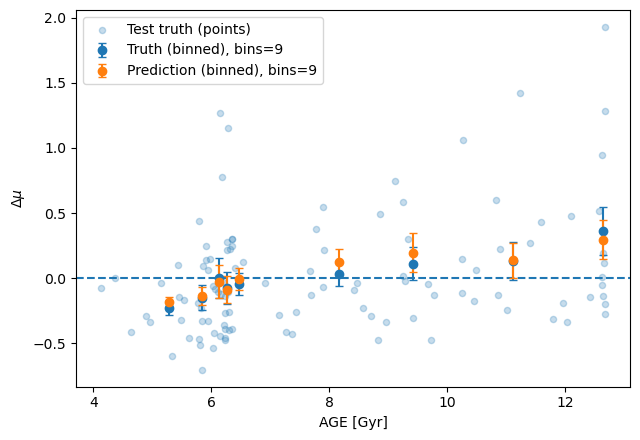

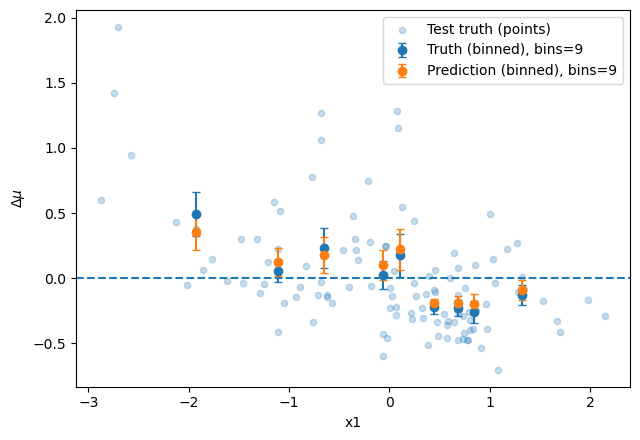

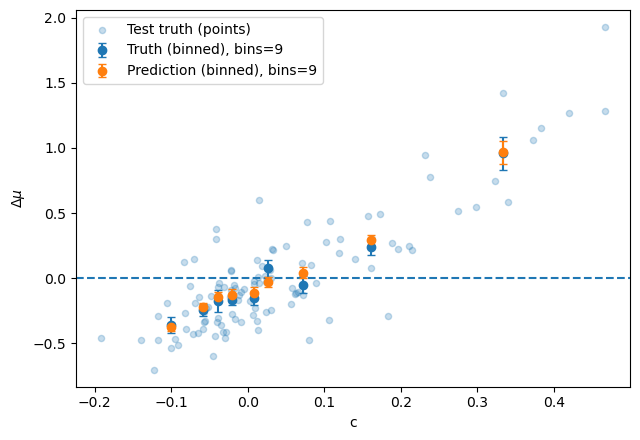

In [3]:
# -----------------------------
# 1) Load your data
# -----------------------------
csv_path = "/Users/pittsburghgraduatestudent/repos/myc21_first_paper/ZTF_DESI_ml_work/ZTF_DESI_data/ZTF_residuals_centered_no_x1_no_c_v2.csv"
df = pd.read_csv(csv_path)

# ---------------------------------------------------------------------------------------
# 2) Choose target we're trying to predict + features that will be used in training
# ---------------------------------------------------------------------------------------
target_col = "residual_centered"

feature_cols = [
    "LOGMSTAR",
    "SFR",
    "VDISP",
    "DN4000",
    "SDSS_g_minus_r",
    "AGE",
    "x1",
    "c"
]

# Building table that ends up selecting only the feature_cols
# and target_col from the data frame we read "df"
df_model = df[feature_cols + [target_col]].copy()


# Separating data into train and test splits here. 
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 4) Build + train model pipeline
# -----------------------------
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        # min_samples_leaf=20,   # trend-smoothing knob
    ))
])

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# -----------------------------
# 5) Basic regression metrics
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)

print(f"N_train = {len(X_train)}  N_test = {len(X_test)}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test  MAE: {mae:.4f}")
print(f"Test   R2: {r2:.4f}")


# -----------------------------
# 6) Trend recovery utilities
# -----------------------------
def choose_nbins(n_points, target_per_bin=12, min_bins=4, max_bins=12):
    """
    Choose a sensible number of bins for a given sample size.
    Example: N=112, target_per_bin=12 -> ~9 bins.
    """
    nb = int(np.floor(n_points / target_per_bin))
    return int(np.clip(nb, min_bins, max_bins))


def binned_means_quantile(x, y, n_bins, min_per_bin=8):
    """
    Quantile (equal-count) binning for x, then mean/SEM of y in each bin.

    Returns:
      centers, means, sems, edges
    or None if too few points.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    n = len(x)
    if n < (min_per_bin * 3):  # need at least a few bins worth
        return None

    # Quantile edges
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))

    # Sometimes identical values cause repeated edges. Unique-ify edges.
    edges = np.unique(edges)
    if len(edges) < 4:  # would yield <3 bins
        return None

    bin_idx = np.digitize(x, edges[1:-1], right=False)

    centers, means, sems = [], [], []
    for b in range(len(edges) - 1):
        mask = bin_idx == b
        if mask.sum() < min_per_bin:
            continue
        xb = x[mask]
        yb = y[mask]
        centers.append(np.median(xb))
        means.append(np.mean(yb))
        sems.append(np.std(yb, ddof=1) / np.sqrt(mask.sum()))

    if len(centers) < 3:
        return None

    return np.array(centers), np.array(means), np.array(sems), edges


def plot_trend_recovery(feature_name, X_test_df, y_true, y_pred,
                        target_per_bin=12, min_per_bin=8,
                        min_bins=4, max_bins=12,
                        xlabel=None, ylabel=r"$\Delta\mu$",
                        show_points=True):
    """
    For a single feature:
      - scatter raw TEST truth
      - binned mean TEST truth
      - binned mean TEST prediction
    with bins chosen automatically from test-set size.
    """
    x = X_test_df[feature_name].to_numpy()

    # Choose bins based on usable points for THIS feature in the test set
    m = np.isfinite(x) & np.isfinite(y_true) & np.isfinite(y_pred)
    n_usable = int(m.sum())

    n_bins = choose_nbins(n_usable, target_per_bin=target_per_bin,
                          min_bins=min_bins, max_bins=max_bins)

    stats = binned_means_quantile(x[m], y_true[m], n_bins=n_bins, min_per_bin=min_per_bin)
    if stats is None:
        print(f"[skip] {feature_name}: usable={n_usable}, chosen_bins={n_bins} (too sparse for binning)")
        return

    centers_true, means_true, sems_true, edges = stats

    # Apply SAME edges to predictions
    x2 = x[m]
    yp2 = np.asarray(y_pred)[m]
    bin_idx = np.digitize(x2, edges[1:-1], right=False)

    centers_pred, means_pred, sems_pred = [], [], []
    for b in range(len(edges) - 1):
        mask = bin_idx == b
        if mask.sum() < min_per_bin:
            continue
        xb = x2[mask]
        yb = yp2[mask]
        centers_pred.append(np.median(xb))
        means_pred.append(np.mean(yb))
        sems_pred.append(np.std(yb, ddof=1) / np.sqrt(mask.sum()))

    # ---- Plot ----
    plt.figure(figsize=(6.5, 4.5))

    if show_points:
        plt.scatter(x[m], np.asarray(y_true)[m], s=20, alpha=0.25, label="Test truth (points)")

    plt.axhline(0.0, linestyle="--")

    plt.errorbar(
        centers_true, means_true, yerr=sems_true,
        fmt="o", capsize=3, label=f"Truth (binned), bins={len(centers_true)}"
    )

    plt.errorbar(
        np.array(centers_pred), np.array(means_pred), yerr=np.array(sems_pred),
        fmt="o", capsize=3, label=f"Prediction (binned), bins={len(centers_pred)}"
    )

    plt.xlabel(xlabel if xlabel else feature_name)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -----------------------------
# 7) Make trend-recovery plots
# -----------------------------
X_test_df = X_test.copy()  # already a DataFrame from train_test_split

pretty_labels = {
    "LOGMSTAR": r"$\log_{10}(M_\star/M_\odot)$",
    "SFR": r"SFR ($M_\odot$/yr)",
    "VDISP": r"VDisp (km/s)",
    "DN4000": r"Dn4000",
    "SDSS_g_minus_r": r"$g-r$ (mag)",
    "AGE": r"AGE [Gyr]"
}

for feat in feature_cols:
    plot_trend_recovery(
        feat,
        X_test_df=X_test_df,
        y_true=y_test,
        y_pred=y_pred_test,
        target_per_bin=12,   # ~10–15 is good for N_test~112
        min_per_bin=8,       # allow bins to exist even in small samples
        min_bins=4,
        max_bins=12,
        xlabel=pretty_labels.get(feat, feat),
        ylabel=r"$\Delta\mu$",
        show_points=True
    )

N_train = 446  N_test = 112
Test RMSE: 0.4614
Test  MAE: 0.3349
Test   R2: -0.0452


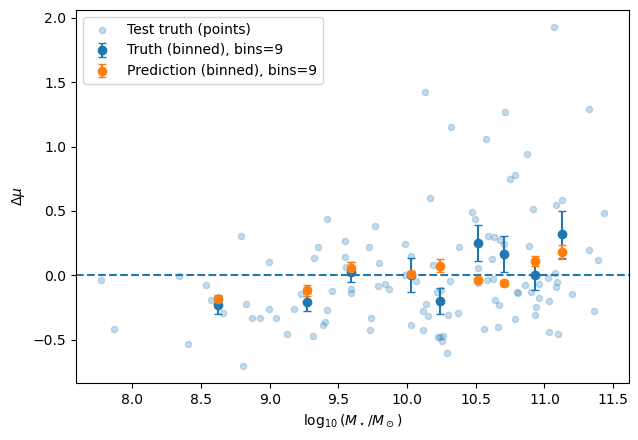

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -----------------------------
# 1) Load your data
# -----------------------------
csv_path = "/Users/pittsburghgraduatestudent/repos/myc21_first_paper/ZTF_DESI_ml_work/ZTF_DESI_data/ZTF_residuals_centered_no_x1_no_c_v2.csv"
df = pd.read_csv(csv_path)

# ---------------------------------------------------------------------------------------
# 2) Choose target we're trying to predict + features that will be used in training
# ---------------------------------------------------------------------------------------
target_col = "residual_centered"

feature_cols = [
    "LOGMSTAR",
    "SFR",
    "VDISP",
    "DN4000",
    "SDSS_g_minus_r",
    "AGE",
    # "x1",
    # "c"
]

# Building table that ends up selecting only the feature_cols
# and target_col from the data frame we read "df"
df_model = df[feature_cols + [target_col]].copy()


# Separating data into train and test splits here. 
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 4) Build + train model pipeline
# -----------------------------
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        # min_samples_leaf=20,   # trend-smoothing knob
    ))
])

model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

# -----------------------------
# 5) Basic regression metrics
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)

print(f"N_train = {len(X_train)}  N_test = {len(X_test)}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test  MAE: {mae:.4f}")
print(f"Test   R2: {r2:.4f}")


# -----------------------------
# 6) Trend recovery utilities (LOGMSTAR only)
# -----------------------------
def choose_nbins(n_points, target_per_bin=12, min_bins=4, max_bins=12):
    """
    Choose a sensible number of bins for a given sample size.
    Example: N=112, target_per_bin=12 -> ~9 bins.
    """
    nb = int(np.floor(n_points / target_per_bin))
    return int(np.clip(nb, min_bins, max_bins))


def binned_means_quantile(x, y, n_bins, min_per_bin=8):
    """
    Quantile (equal-count) binning for x, then mean/SEM of y in each bin.

    Returns:
      centers, means, sems, edges
    or None if too few points.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    n = len(x)
    if n < (min_per_bin * 3):  # need at least a few bins worth
        return None

    # Quantile edges
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))

    # Sometimes identical values cause repeated edges. Unique-ify edges.
    edges = np.unique(edges)
    if len(edges) < 4:  # would yield <3 bins
        return None

    bin_idx = np.digitize(x, edges[1:-1], right=False)

    centers, means, sems = [], [], []
    for b in range(len(edges) - 1):
        mask = bin_idx == b
        if mask.sum() < min_per_bin:
            continue
        xb = x[mask]
        yb = y[mask]
        centers.append(np.median(xb))
        means.append(np.mean(yb))
        sems.append(np.std(yb, ddof=1) / np.sqrt(mask.sum()))

    if len(centers) < 3:
        return None

    return np.array(centers), np.array(means), np.array(sems), edges


# -----------------------------
# 7) Trend recovery plot for LOGMSTAR only
# -----------------------------
feature_name = "LOGMSTAR"

x = X_test[feature_name].to_numpy()
y_true = np.asarray(y_test)
y_pred = np.asarray(y_pred_test)

# Keep only rows where x, y_true, y_pred are finite
m = np.isfinite(x) & np.isfinite(y_true) & np.isfinite(y_pred)
n_usable = int(m.sum())

# Choose an appropriate number of bins based on test set size
n_bins = choose_nbins(n_usable, target_per_bin=12, min_bins=4, max_bins=12)

# Compute binned trend for truth in the test set
stats = binned_means_quantile(x[m], y_true[m], n_bins=n_bins, min_per_bin=8)
if stats is None:
    raise RuntimeError(f"Not enough usable data to bin {feature_name}. usable={n_usable}, bins={n_bins}")

centers_true, means_true, sems_true, edges = stats

# Apply SAME edges to predictions
x2 = x[m]
yp2 = y_pred[m]
bin_idx = np.digitize(x2, edges[1:-1], right=False)

centers_pred, means_pred, sems_pred = [], [], []
for b in range(len(edges) - 1):
    mask = bin_idx == b
    if mask.sum() < 8:
        continue
    xb = x2[mask]
    yb = yp2[mask]
    centers_pred.append(np.median(xb))
    means_pred.append(np.mean(yb))
    sems_pred.append(np.std(yb, ddof=1) / np.sqrt(mask.sum()))

# ---- Plot ----
plt.figure(figsize=(6.5, 4.5))

# Raw test set points (truth)
plt.scatter(x[m], y_true[m], s=20, alpha=0.25, label="Test truth (points)")

# Horizontal zero line
plt.axhline(0.0, linestyle="--")

# Binned truth
plt.errorbar(
    centers_true, means_true, yerr=sems_true,
    fmt="o", capsize=3, label=f"Truth (binned), bins={len(centers_true)}"
)

# Binned predictions
plt.errorbar(
    np.array(centers_pred), np.array(means_pred), yerr=np.array(sems_pred),
    fmt="o", capsize=3, label=f"Prediction (binned), bins={len(centers_pred)}"
)

plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel(r"$\Delta\mu$")
plt.legend()
plt.tight_layout()
plt.show()